About Dataset
Description
The dataset contains disease names along with the symptoms faced by the respective patient. There are a total of 773 unique diseases and 377 symptoms, with ~246,000 rows. The dataset was artificially generated, preserving Symptom Severity and Disease Occurrence Possibility.

Interpretation Info
Several distinct groups of symptoms might all be indicators of the same disease. There may even be one single symptom contributing to a disease in a row or sample. This is an indicator of a very high correlation between the symptom and that particular disease.
A larger number of rows for a particular disease corresponds to its higher probability of occurrence in the real world. Similarly, in a row, if the feature vector has the occurrence of a single symptom, it implies that this symptom has more correlation to classify the disease than any one symptom of a feature vector with multiple symptoms in another sample.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, top_k_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import xgboost as xgb
import joblib

# Set plot style for the graphs
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
from google.colab import drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

print("Loading data...")
csv_path = "/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(csv_path)

print(f"Initial Dataset Shape: {df.shape}")
# Display the first 5 rows so the mentor can visually inspect the raw data
df.head()

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
Initial Dataset Shape: (246945, 378)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
target_col = "diseases"
feature_cols = [c for c in df.columns if c != target_col]

# 1. Cast symptom columns to uint8 -> massively cuts RAM
X = df[feature_cols].astype(np.uint8)
y_raw = df[target_col]
print(f"Original -> Features: {X.shape[1]}, Classes: {y_raw.nunique()}")

# 2. Drop zero-variance features (symptoms that are all 0s or all 1s)
nunique = X.nunique()
useless_cols = nunique[nunique <= 1].index.tolist()
if useless_cols:
    print(f"Dropping {len(useless_cols)} zero-variance columns.")
    X = X.drop(columns=useless_cols)

# 3. Handle rare classes (<2 samples) to prevent stratified split crashing
class_counts = y_raw.value_counts()
rare_classes = class_counts[class_counts < 2].index
if len(rare_classes) > 0:
    print(f"Dropping {len(rare_classes)} classes with <2 samples.")
    mask = ~y_raw.isin(rare_classes)
    X, y_raw = X[mask], y_raw[mask]

# 4. Label Encode the Target Variable
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)

print(f"Final Cleaned Data -> Rows: {X.shape[0]}, Features: {X.shape[1]}, Classes: {num_classes}")


Original -> Features: 377, Classes: 773
Dropping 49 zero-variance columns.
Dropping 19 classes with <2 samples.
Final Cleaned Data -> Rows: 246926, Features: 328, Classes: 754


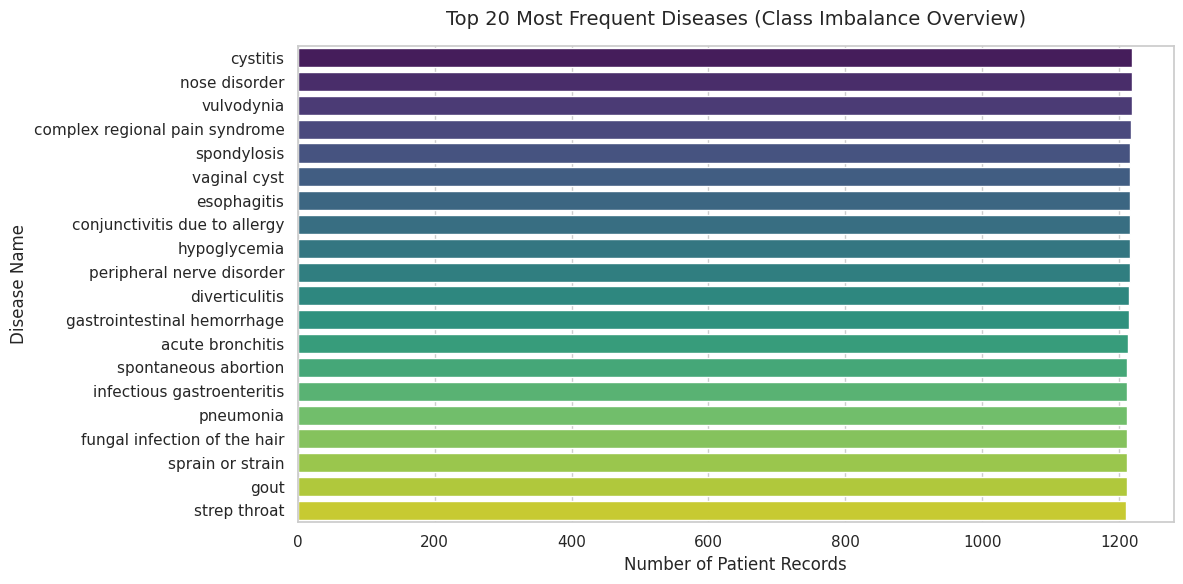

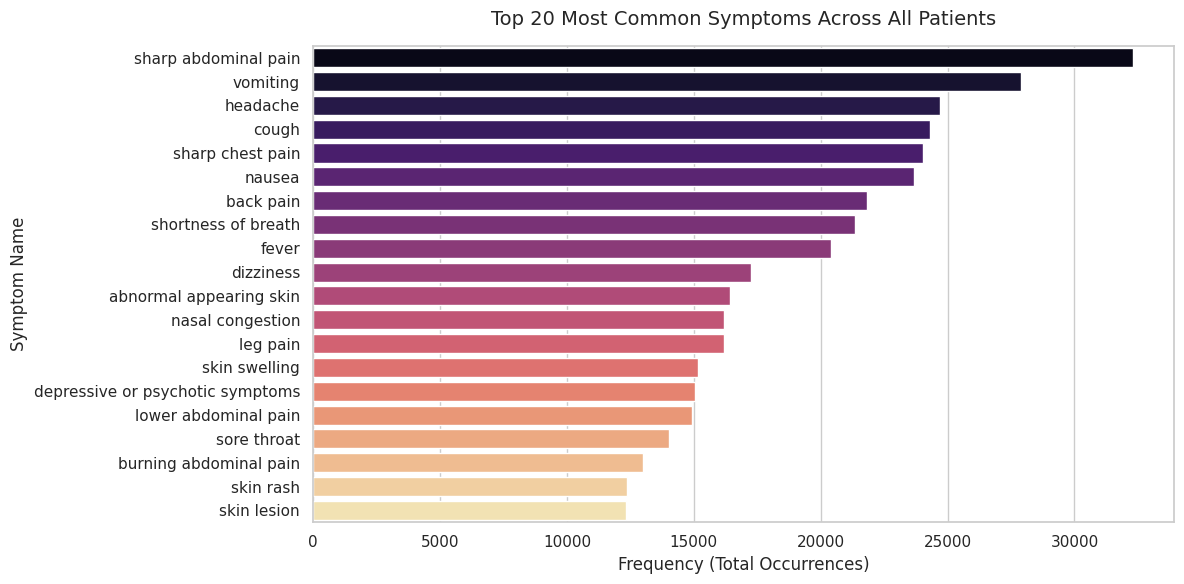

In [4]:
# Graph 1: Top 20 Most Frequent Diseases (Demonstrating Class Imbalance)
plt.figure(figsize=(12, 6))
top_diseases = y_raw.value_counts().nlargest(20)
sns.barplot(x=top_diseases.values, y=top_diseases.index, hue=top_diseases.index, palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Diseases (Class Imbalance Overview)', fontsize=14, pad=15)
plt.xlabel('Number of Patient Records')
plt.ylabel('Disease Name')
plt.tight_layout()
plt.show()

# Graph 2: Top 20 Most Common Symptoms Overall
plt.figure(figsize=(12, 6))
top_symptoms = X.sum().nlargest(20)
sns.barplot(x=top_symptoms.values, y=top_symptoms.index, hue=top_symptoms.index, palette='magma', legend=False)
plt.title('Top 20 Most Common Symptoms Across All Patients', fontsize=14, pad=15)
plt.xlabel('Frequency (Total Occurrences)')
plt.ylabel('Symptom Name')
plt.tight_layout()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data:  {X_test.shape[0]} rows")


Training Data: 197540 rows
Testing Data:  49386 rows


In [6]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "multi:softprob",
    "num_class": num_classes,
    "eval_metric": ["mlogloss", "merror"],
    "tree_method": "hist",
    "device": "cuda", # GPU acceleration
    "max_depth": 8,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "min_child_weight": 2,
    "reg_lambda": 1.0,
    "seed": RANDOM_STATE,
}

print("Training XGBoost on GPU...")
evals_result = {} # We must pass this empty dictionary to capture data for our graph!

model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, "train") , (dtest, "val")],
    early_stopping_rounds=25,
    evals_result=evals_result,
    verbose_eval=25,
)

print(f"\nTraining stopped. Best iteration: {model.best_iteration}")


Training XGBoost on GPU...
[0]	train-mlogloss:4.05472	train-merror:0.66626	val-mlogloss:4.07797	val-merror:0.67053
[25]	train-mlogloss:0.85071	train-merror:0.13947	val-mlogloss:0.92498	val-merror:0.16422
[50]	train-mlogloss:0.49829	train-merror:0.11414	val-mlogloss:0.59465	val-merror:0.15535
[72]	train-mlogloss:0.39400	train-merror:0.10295	val-mlogloss:0.51194	val-merror:0.15751

Training stopped. Best iteration: 47


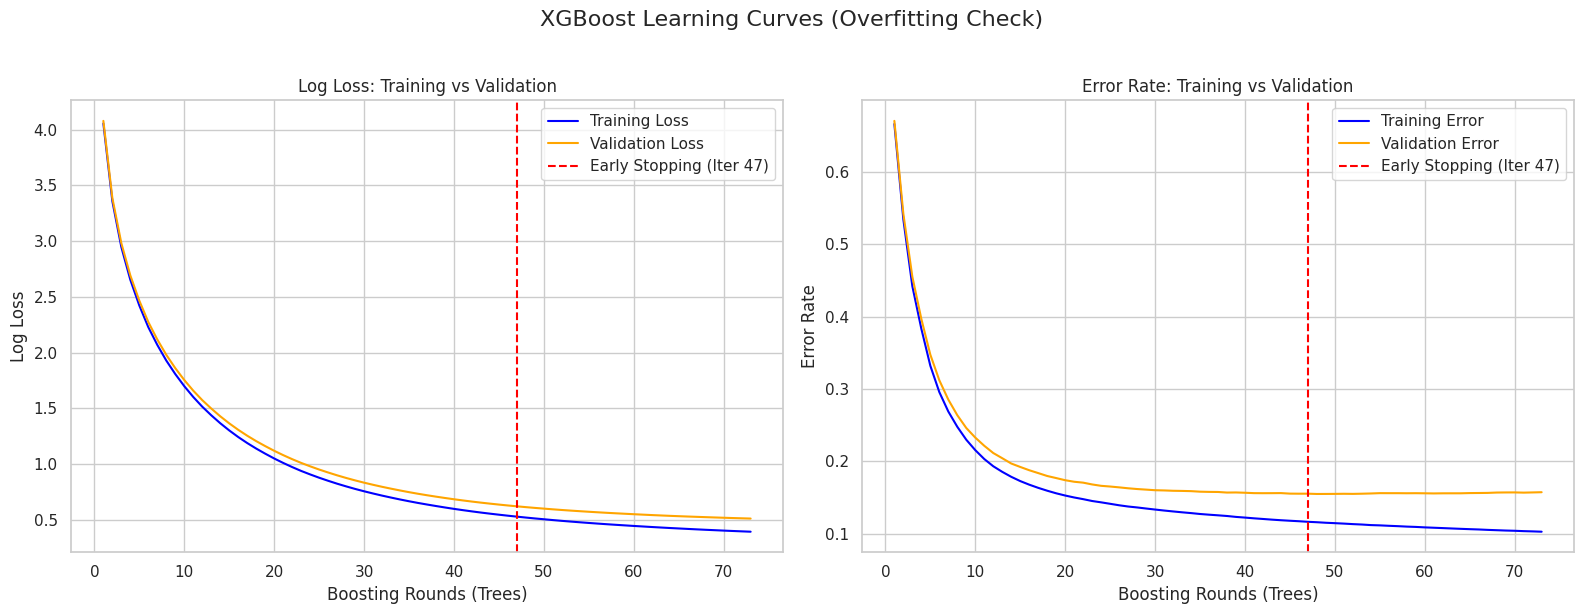

In [7]:
# Extract the metric arrays from the evals_result dictionary
train_loss = evals_result['train']['mlogloss']
val_loss = evals_result['val']['mlogloss']
train_error = evals_result['train']['merror']
val_error = evals_result['val']['merror']
epochs = range(1, len(train_loss) + 1)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Log Loss (mlogloss)
ax1.plot(epochs, train_loss, label='Training Loss', color='blue')
ax1.plot(epochs, val_loss, label='Validation Loss', color='orange')
ax1.axvline(x=model.best_iteration, color='red', linestyle='--', label=f'Early Stopping (Iter {model.best_iteration})')
ax1.set_title('Log Loss: Training vs Validation')
ax1.set_xlabel('Boosting Rounds (Trees)')
ax1.set_ylabel('Log Loss')
ax1.legend()

# Graph 2: Classification Error (merror)
ax2.plot(epochs, train_error, label='Training Error', color='blue')
ax2.plot(epochs, val_error, label='Validation Error', color='orange')
ax2.axvline(x=model.best_iteration, color='red', linestyle='--', label=f'Early Stopping (Iter {model.best_iteration})')
ax2.set_title('Error Rate: Training vs Validation')
ax2.set_xlabel('Boosting Rounds (Trees)')
ax2.set_ylabel('Error Rate')
ax2.legend()

plt.suptitle("XGBoost Learning Curves (Overfitting Check)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [11]:
y_pred_proba = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))
y_pred_top1 = np.argmax(y_pred_proba, axis=1)

# Basic Accuracy
top1_acc = accuracy_score(y_test, y_pred_top1)
top3_acc = top_k_accuracy_score(y_test, y_pred_proba, k=3, labels=np.arange(num_classes))
top5_acc = top_k_accuracy_score(y_test, y_pred_proba, k=5, labels=np.arange(num_classes))

# Precision, Recall, F1
weighted_precision = precision_score(y_test, y_pred_top1, average='weighted', zero_division=0)
weighted_recall = recall_score(y_test, y_pred_top1, average='weighted', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred_top1, average='weighted', zero_division=0)
macro_f1 = f1_score(y_test, y_pred_top1, average='macro', zero_division=0)

# ROC-AUC (The Medical Gold Standard)
# FIX: Filter out rare classes that accidentally didn't make it into the 20% test split
present_classes = np.unique(y_test)
y_pred_proba_present = y_pred_proba[:, present_classes]

# Re-normalize the probabilities so they sum to exactly 1.0 (Scikit-learn strict requirement)
y_pred_proba_present = y_pred_proba_present / y_pred_proba_present.sum(axis=1, keepdims=True)

roc_auc_weighted = roc_auc_score(y_test, y_pred_proba_present, multi_class='ovr', average='weighted', labels=present_classes)
roc_auc_macro = roc_auc_score(y_test, y_pred_proba_present, multi_class='ovr', average='macro', labels=present_classes)

print("=== Standard Accuracy Metrics ===")
print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-3 Accuracy: {top3_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}\n")

print("=== Advanced Imbalanced Metrics ===")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-Score:  {weighted_f1:.4f}")
print(f"Macro F1-Score:     {macro_f1:.4f} (Performance on rare diseases)\n")

print("=== ROC-AUC Scores (Class Separation Power) ===")
print(f"Weighted ROC-AUC:   {roc_auc_weighted:.4f}")
print(f"Macro ROC-AUC:      {roc_auc_macro:.4f}")


=== Standard Accuracy Metrics ===
Top-1 Accuracy: 0.8449
Top-3 Accuracy: 0.9460
Top-5 Accuracy: 0.9677

=== Advanced Imbalanced Metrics ===
Weighted Precision: 0.8428
Weighted Recall:    0.8449
Weighted F1-Score:  0.8414
Macro F1-Score:     0.6472 (Performance on rare diseases)

=== ROC-AUC Scores (Class Separation Power) ===
Weighted ROC-AUC:   0.9994
Macro ROC-AUC:      0.9935


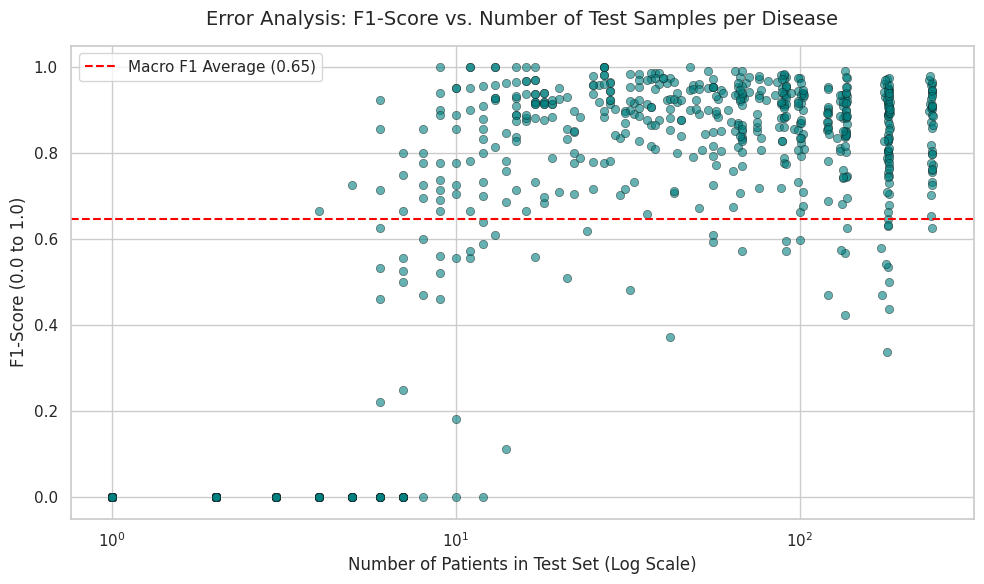

In [12]:
# Calculate individual F1-score for every single disease
f1_per_class = f1_score(y_test, y_pred_top1, average=None, zero_division=0)

# Count how many patients in the test set actually had each disease
support_per_class = pd.Series(y_test).value_counts().sort_index()

# Plot the relationship between 'Amount of Data' and 'Model Accuracy'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=support_per_class.values, y=f1_per_class, alpha=0.6, color='teal', edgecolor='k')
plt.xscale('log') # Use a log scale because some diseases have 10,000 patients and others have 2
plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1 Average ({macro_f1:.2f})')

plt.title('Error Analysis: F1-Score vs. Number of Test Samples per Disease', fontsize=14, pad=15)
plt.xlabel('Number of Patients in Test Set (Log Scale)')
plt.ylabel('F1-Score (0.0 to 1.0)')
plt.legend()
plt.tight_layout()
plt.show()

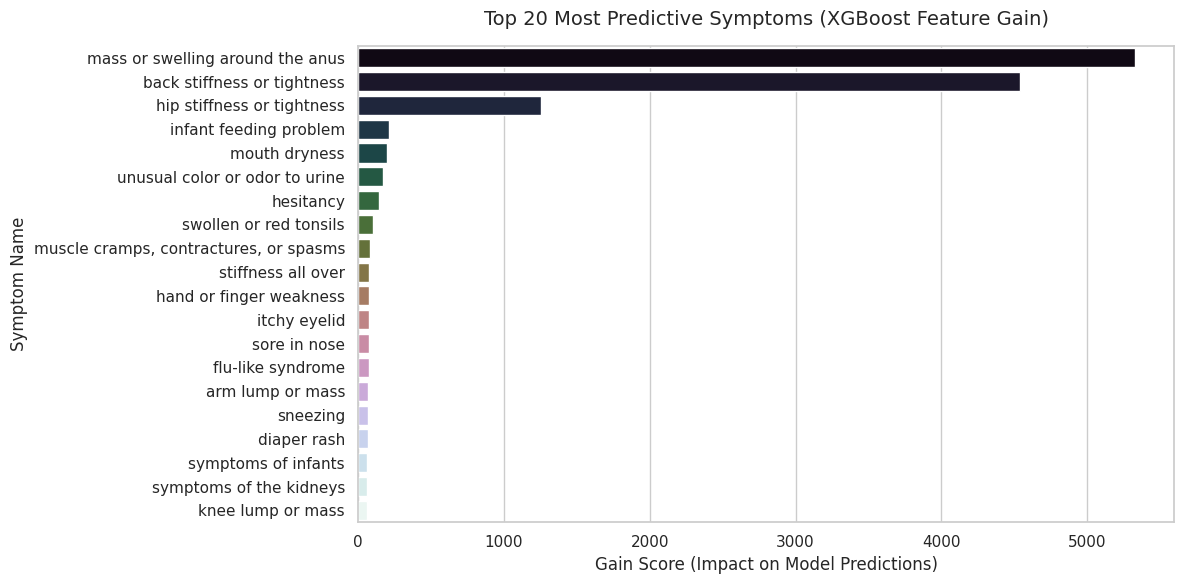

In [13]:
# Extract Feature Gain (How much mathematical value each symptom added)
importance = model.get_score(importance_type='gain')

# Convert dictionary to DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Gain': list(importance.values())
})

# Sort and grab the top 20
importance_df = importance_df.sort_values(by='Gain', ascending=False).head(20)

# Plotting the Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Gain', y='Feature', hue='Feature', data=importance_df, palette='cubehelix', legend=False)
plt.title('Top 20 Most Predictive Symptoms (XGBoost Feature Gain)', fontsize=14, pad=15)
plt.xlabel('Gain Score (Impact on Model Predictions)')
plt.ylabel('Symptom Name')
plt.tight_layout()
plt.show()


In [14]:
# -----------------------------------------------------------------
# 7. Feature importance (useful for your Symptom Analysis module /
#    report -- shows which symptoms drive predictions)
# -----------------------------------------------------------------
importance = model.get_score(importance_type="gain")
top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:20]
print("\nTop 20 most predictive symptoms (by gain):")
for feat, score in top_features:
    print(f"  {feat}: {score:.2f}")


Top 20 most predictive symptoms (by gain):
  mass or swelling around the anus: 5329.08
  back stiffness or tightness: 4541.90
  hip stiffness or tightness: 1254.65
  infant feeding problem: 208.98
  mouth dryness: 198.05
  unusual color or odor to urine: 172.20
  hesitancy: 144.54
  swollen or red tonsils: 104.17
  muscle cramps, contractures, or spasms: 79.60
  stiffness all over: 74.30
  hand or finger weakness: 73.60
  itchy eyelid: 71.70
  sore in nose: 70.83
  flu-like syndrome: 70.62
  arm lump or mass: 69.43
  sneezing: 67.05
  diaper rash: 66.52
  symptoms of infants: 63.24
  symptoms of the kidneys: 62.28
  knee lump or mass: 61.71
